In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

from torch.utils.tensorboard import SummaryWriter


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
exp_name = 'rossler_14k_loss_rk4'
writer = SummaryWriter(log_dir=f'runs/{exp_name}')

dt          = 0.01
Nbatch      = 10000
tepoch      = 100    # шагов градиентного спуска в "эпоху"
tvalid      = 3      # шагов для валидации
num_epochs  = 14000
hidden_size = 100 

In [3]:
mu_u = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
su   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_p = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sp   = torch.tensor([10.0, 10.0, 10.0], dtype=torch.float32, device=device)
mu_g = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device=device)
sg   = torch.tensor([14.0, 101.0, 142.0], dtype=torch.float32, device=device)

In [4]:
def f(u, p):
    x, y, z = u[...,0], u[...,1], u[...,2]
    a, b, c = p[...,0], p[...,1], p[...,2]
    dx = -y - z
    dy =  x + a*y
    dz =  b + z*(x - c)
    
    return torch.stack([dx, dy, dz], dim=-1)


def rossler_rhs(_, y, a, b, c):
    x, y1, z = y
    dx = -y1 - z
    dy =  x + a * y1
    dz =  b + z * (x - c)
    return [dx, dy, dz]

In [5]:
class RosslerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(6, hidden_size)
        self.act = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, 3)

    def forward(self, u, p):

        u0 = (u - mu_u) / su
        p0 = (p - mu_p) / sp

        h  = self.act(self.fc1(torch.cat([u0, p0], dim=-1)))
        g  = self.fc2(h)

        d = dt * (g * sg + mu_g)
        return d

model = RosslerNet().to(device)

In [6]:
initial_lr = 0.1
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

def get_lr(step):
    return initial_lr / (1.0 + 0.96 * step / (30 * tepoch))

mse_loss = nn.MSELoss()

def compute_error_rk2(u, p, d):

    k1 = f(u, p)
    k2 = f(u + d, p)
    
    e  = d - 0.5 * dt * (k1 + k2)
    
    return e

def compute_error_rk4(u, p, d):

    k1 = f(u, p)
    k2 = f(u + 0.5 * dt * k1, p)
    k3 = f(u + 0.5 * dt * k2, p)
    k4 = f(u + dt * k3, p)

    e = d - dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0

    return e

def MRNE(e, u):
    num = torch.sum(torch.abs(e), dim=-1)
    den = torch.sum(torch.abs(u), dim=-1)
    return torch.mean(num / den)

In [7]:
best_mrne   = float('inf')
global_step = 0

for epoch in range(1, num_epochs + 1):

    model.train()
    train_losses = []
    
    for _ in range(tepoch):

        u_batch = torch.randn(Nbatch, 3, device=device) * su + mu_u
        p_batch = torch.randn(Nbatch, 3, device=device) * sp + mu_p

        optimizer.zero_grad()
        d = model(u_batch, p_batch)
        e = compute_error_rk4(u_batch, p_batch, d)

        loss  = mse_loss(e, torch.zeros_like(e))
        loss.backward()
        optimizer.step()

        global_step += 1
        lr = get_lr(global_step)
        for g in optimizer.param_groups:
            g['lr'] = lr
            
        writer.add_scalar('Train/Loss', loss.item(), global_step)
        writer.add_scalar('Train/LR',   lr,          global_step)
        train_losses.append(loss.item())


    model.eval()
    losses = []
    mrnes  = []
    with torch.no_grad():
        for _ in range(tvalid):
            u_val = torch.randn(Nbatch, 3, device=device) * su + mu_u
            p_val = torch.randn(Nbatch, 3, device=device) * sp + mu_p
            
            d = model(u_val, p_val)
            e_val = compute_error_rk4(u_val, p_val, d)
            
            losses.append(mse_loss(e_val, torch.zeros_like(e_val)).item())
            mrnes.append(MRNE(e_val, u_val).item())

    val_loss = np.mean(losses)
    val_mrne = np.mean(mrnes)
    
    writer.add_scalar('Val/Loss', val_loss, epoch)
    writer.add_scalar('Val/MRNE', val_mrne, epoch)

    if val_mrne < best_mrne:
        best_mrne = val_mrne
        torch.save(model.state_dict(), f'ckpt/{exp_name}.pt')

    if epoch % 1000 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d}  |  Val MSE = {val_loss:.3e}  |  Val MRNE = {val_mrne:.3e}")

Epoch     1  |  Val MSE = 1.680e-01  |  Val MRNE = 1.822e-02
Epoch  1000  |  Val MSE = 4.294e-07  |  Val MRNE = 6.534e-05
Epoch  2000  |  Val MSE = 2.254e-07  |  Val MRNE = 3.956e-05
Epoch  3000  |  Val MSE = 1.794e-07  |  Val MRNE = 4.482e-05
Epoch  4000  |  Val MSE = 2.240e-07  |  Val MRNE = 4.785e-05
Epoch  5000  |  Val MSE = 7.005e-08  |  Val MRNE = 2.525e-05
Epoch  6000  |  Val MSE = 6.652e-08  |  Val MRNE = 2.493e-05
Epoch  7000  |  Val MSE = 3.697e-08  |  Val MRNE = 1.780e-05
Epoch  8000  |  Val MSE = 4.304e-08  |  Val MRNE = 1.915e-05
Epoch  9000  |  Val MSE = 5.980e-08  |  Val MRNE = 2.179e-05
Epoch 10000  |  Val MSE = 2.950e-08  |  Val MRNE = 1.604e-05
Epoch 11000  |  Val MSE = 2.686e-08  |  Val MRNE = 1.502e-05
Epoch 12000  |  Val MSE = 2.530e-08  |  Val MRNE = 1.473e-05
Epoch 13000  |  Val MSE = 7.593e-08  |  Val MRNE = 1.527e-05
Epoch 14000  |  Val MSE = 3.225e-08  |  Val MRNE = 1.694e-05


In [22]:
import time

RK45  0.030776023864746094
Model  1.6684470176696777


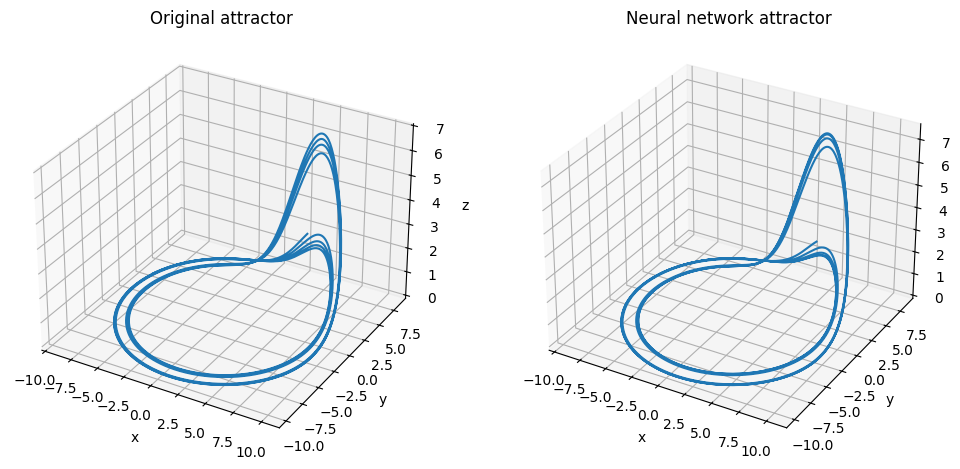

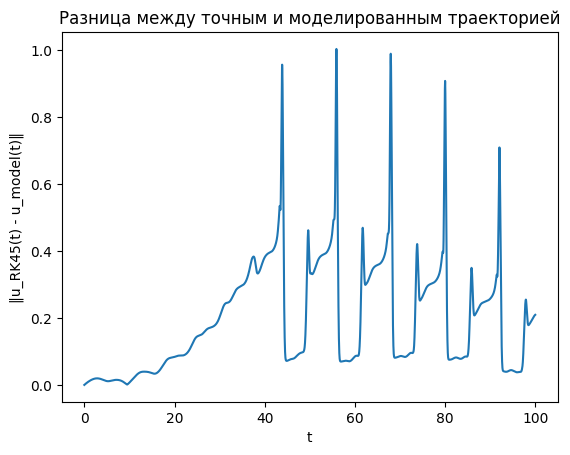

In [ ]:
exp_name = 'rossler_14k_loss_rk4'

a, b, c = 0.1, 0.1, 6.
transient_process = 5000
method = 'RK45'

t0, t1, dt_vis = 0.0, 100.0, dt
t_eval = np.arange(t0, t1+dt_vis, dt_vis)


y0 = np.array([1.0, 1.0, 1.0], dtype=np.float32)

sol = solve_ivp(
    rossler_rhs,
    (t0, t1),
    y0,
    args=(a, b, c),
    t_eval=t_eval,
    method=method
)


model.load_state_dict(torch.load(f'ckpt/{exp_name}.pt', map_location=device))
model.to(device).eval()

us = torch.empty((len(t_eval), 3), device=device)
u = torch.tensor(y0, device=device)
p = torch.tensor([a, b, c], dtype=torch.float32, device=device)

with torch.no_grad():
    for i in range(len(t_eval)):
        us[i] = u
        d = model(u.unsqueeze(0), p.unsqueeze(0)).squeeze(0)
        u = u + d

u_model = us.cpu().numpy()


fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

ax1.plot(sol.y[0][transient_process:], sol.y[1][transient_process:], sol.y[2][transient_process:], label=method)
ax2.plot(u_model[:,0][transient_process:], u_model[:,1][transient_process:], u_model[:,2][transient_process:], label='Model')

ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title("Original attractor")

ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.set_title("Neural network attractor")

plt.show()


err = np.linalg.norm(sol.y.T - u_model, axis=1)

plt.figure()
plt.plot(t_eval, err)
plt.xlabel('t')
plt.ylabel(f'‖u_{method}(t) - u_model(t)‖')
plt.title('Разница между точным и моделированным траекторией')
plt.show()